# GuidaPlate — Clinical Score Risk Labels (v3)
## Notebook 03c — Weighted KDOQI clinical score labeling

**Does not modify** notebook 03 or `outputs/stats/05_risk_labels.csv`.

Produces `outputs/stats/05_risk_labels_v3.csv` with continuous clinical scores
and v3 risk labels for leakage-reduced XGBoost training (notebook 04c).


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')
%matplotlib inline


def project_root() -> Path:
    p = Path.cwd().resolve()
    if p.name == 'notebooks':
        return p.parent
    if (p / 'data' / 'processed' / 'ckd_cohort_final.csv').exists():
        return p
    if (p.parent / 'data' / 'processed' / 'ckd_cohort_final.csv').exists():
        return p.parent
    return p

ROOT = project_root()
FIG_DIR = ROOT / 'outputs' / 'figures'
STATS_DIR = ROOT / 'outputs' / 'stats'
MODEL_DIR = ROOT / 'models'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(STATS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

KDOQI = {
    'G2':  {'potassium': 3500, 'phosphorus': 1000, 'protein_per_kg': 0.8, 'sodium': 2300},
    'G3a': {'potassium': 3000, 'phosphorus': 800,  'protein_per_kg': 0.6, 'sodium': 2300},
    'G3b': {'potassium': 3000, 'phosphorus': 800,  'protein_per_kg': 0.6, 'sodium': 2300},
    'G4':  {'potassium': 2500, 'phosphorus': 700,  'protein_per_kg': 0.55, 'sodium': 2300},
}

WEIGHTS = {
    'potassium': 0.35,
    'phosphorus': 0.30,
    'protein_per_kg': 0.25,
    'sodium': 0.10,
}

RISK_CLASSES = ['LOW', 'MODERATE', 'HIGH']
STAGE_ENCODE = {'G2': 1, 'G3a': 2, 'G3b': 3, 'G4': 4}
RISK_ENCODE = {c: i for i, c in enumerate(RISK_CLASSES)}

def compute_clinical_score(row):
    stage = row['ckd_stage']
    if stage not in KDOQI:
        return np.nan
    limits = KDOQI[stage]
    score = 0.0
    for nutrient, weight in WEIGHTS.items():
        if pd.isna(row.get(nutrient)):
            continue
        ratio = row[nutrient] / limits[nutrient]
        if ratio > 1.0:
            score += weight * (1 + (ratio - 1) * 2)
        else:
            score += weight * ratio
    return score

def assign_clinical_risk_label(row):
    score = compute_clinical_score(row)
    if pd.isna(score):
        return None
    if score >= 1.2:
        return 'HIGH'
    if score >= 0.7:
        return 'MODERATE'
    return 'LOW'

def assign_rule_baseline_label(row):
    stage = row['ckd_stage']
    if stage not in KDOQI:
        return None
    limits = KDOQI[stage]
    exceeded = 0
    for nutrient in ['potassium', 'phosphorus', 'protein_per_kg', 'sodium']:
        if pd.notna(row.get(nutrient)) and row[nutrient] > limits[nutrient]:
            exceeded += 1
    if exceeded >= 2:
        return 'HIGH'
    if exceeded == 1:
        return 'MODERATE'
    return 'LOW'

print(f'Project root: {ROOT}')


Project root: /Users/jade/GUIDAPLATE


## Section 1 — Load Data


In [2]:
labels_orig = pd.read_csv(STATS_DIR / '05_risk_labels.csv')
cohort = pd.read_csv(ROOT / 'data' / 'processed' / 'ckd_cohort_final.csv')

df = cohort.merge(
    labels_orig[['SEQN', 'risk_label']].rename(columns={'risk_label': 'risk_label_original'}),
    on='SEQN', how='inner',
)
nutrient_cols = ['potassium', 'phosphorus', 'protein_per_kg', 'sodium']
print(f'Merged shape: {df.shape}')
print('Original label distribution:')
print(df['risk_label_original'].value_counts().reindex(RISK_CLASSES))


Merged shape: (1862, 11)
Original label distribution:
risk_label_original
LOW          640
MODERATE     203
HIGH        1019
Name: count, dtype: int64


## Section 2 — Weighted Clinical Score Function


In [3]:
df['clinical_score'] = df.apply(compute_clinical_score, axis=1)
df['risk_label_v3'] = df.apply(assign_clinical_risk_label, axis=1)
df = df.dropna(subset=['risk_label_v3'])

print('v3 label distribution:')
print(df['risk_label_v3'].value_counts().reindex(RISK_CLASSES))
print(f'\nClinical score range: {df["clinical_score"].min():.3f} — {df["clinical_score"].max():.3f}')


v3 label distribution:
risk_label_v3
LOW         633
MODERATE    494
HIGH        735
Name: count, dtype: int64

Clinical score range: 0.000 — 6.793


## Section 3 — Label Comparison Analysis


In [4]:
changed = df['risk_label_original'] != df['risk_label_v3']
n_changed = int(changed.sum())
pct_changed = 100 * n_changed / len(df)
print('=' * 50)
print('LABEL COMPARISON: Original vs v3')
print('=' * 50)
print(f'Changed: {n_changed} / {len(df)} ({pct_changed:.1f}%)')
print('\nChanges by original class:')
for cls in RISK_CLASSES:
    sub = df[df['risk_label_original'] == cls]
    ch = (sub['risk_label_original'] != sub['risk_label_v3']).sum()
    print(f'  {cls}: {ch} changed ({100*ch/len(sub):.1f}%)')

agreement = pd.crosstab(df['risk_label_original'], df['risk_label_v3'], margins=True)
print('\nAgreement matrix (original rows × v3 cols):')
print(agreement)


LABEL COMPARISON: Original vs v3
Changed: 377 / 1862 (20.2%)

Changes by original class:
  LOW: 48 changed (7.5%)
  MODERATE: 43 changed (21.2%)
  HIGH: 286 changed (28.1%)

Agreement matrix (original rows × v3 cols):
risk_label_v3        HIGH  LOW  MODERATE   All
risk_label_original                           
HIGH                  733    0       286  1019
LOW                     0  592        48   640
MODERATE                2   41       160   203
All                   735  633       494  1862


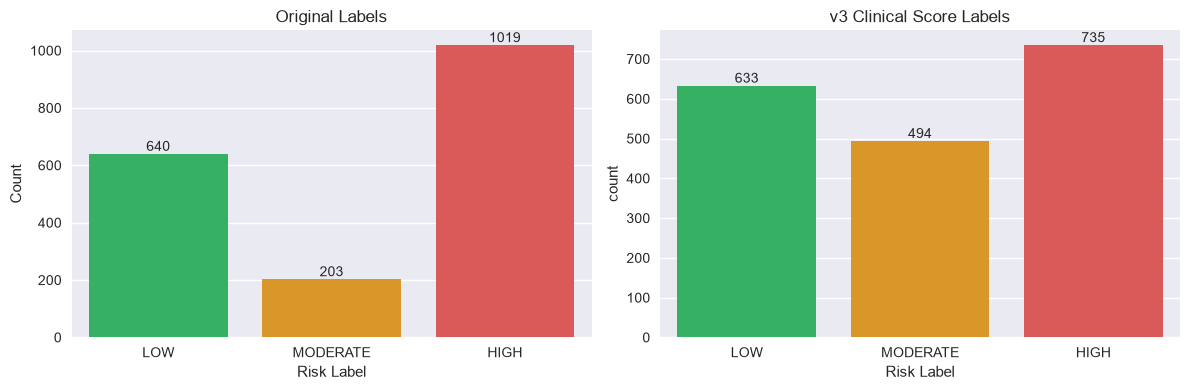

Saved: /Users/jade/GUIDAPLATE/outputs/figures/xgb_v3_01_class_dist.png


In [5]:
# DIAGRAM 1 — Side-by-side class distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette = {'LOW': '#22c55e', 'MODERATE': '#f59e0b', 'HIGH': '#ef4444'}

sns.countplot(x=df['risk_label_original'], ax=axes[0], palette=palette, order=RISK_CLASSES)
axes[0].set_title('Original Labels')
axes[0].set_xlabel('Risk Label')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

sns.countplot(x=df['risk_label_v3'], ax=axes[1], palette=palette, order=RISK_CLASSES)
axes[1].set_title('v3 Clinical Score Labels')
axes[1].set_xlabel('Risk Label')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')
plt.tight_layout()
plt.savefig(FIG_DIR / 'xgb_v3_01_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "xgb_v3_01_class_dist.png"}')


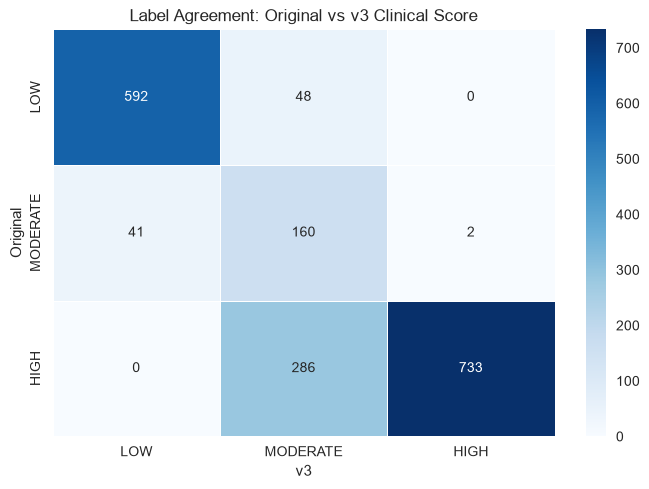

Saved: /Users/jade/GUIDAPLATE/outputs/figures/xgb_v3_02_agreement.png


In [6]:
# DIAGRAM 2 — Agreement heatmap
ct = pd.crosstab(df['risk_label_original'], df['risk_label_v3'], rownames=['Original'], colnames=['v3'])
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(ct.reindex(index=RISK_CLASSES, columns=RISK_CLASSES, fill_value=0),
            annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Label Agreement: Original vs v3 Clinical Score')
plt.tight_layout()
plt.savefig(FIG_DIR / 'xgb_v3_02_agreement.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "xgb_v3_02_agreement.png"}')


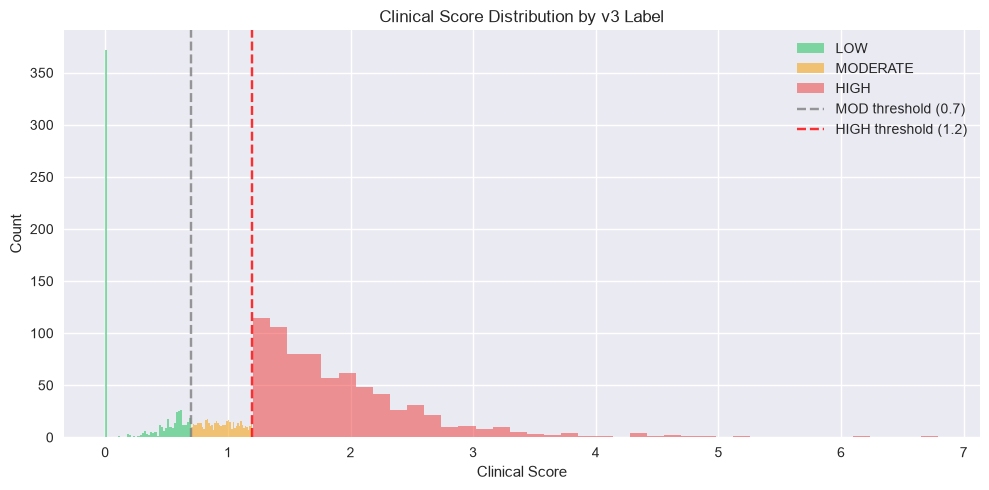

Saved: /Users/jade/GUIDAPLATE/outputs/figures/xgb_v3_03_score_dist.png


In [7]:
# DIAGRAM 3 — Clinical score distribution by v3 label
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'LOW': '#22c55e', 'MODERATE': '#f59e0b', 'HIGH': '#ef4444'}
for label in RISK_CLASSES:
    ax.hist(df.loc[df['risk_label_v3'] == label, 'clinical_score'],
            bins=40, alpha=0.55, label=label, color=colors[label])
ax.axvline(0.7, color='gray', linestyle='--', alpha=0.8, label='MOD threshold (0.7)')
ax.axvline(1.2, color='red', linestyle='--', alpha=0.8, label='HIGH threshold (1.2)')
ax.set_xlabel('Clinical Score')
ax.set_ylabel('Count')
ax.set_title('Clinical Score Distribution by v3 Label')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'xgb_v3_03_score_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "xgb_v3_03_score_dist.png"}')


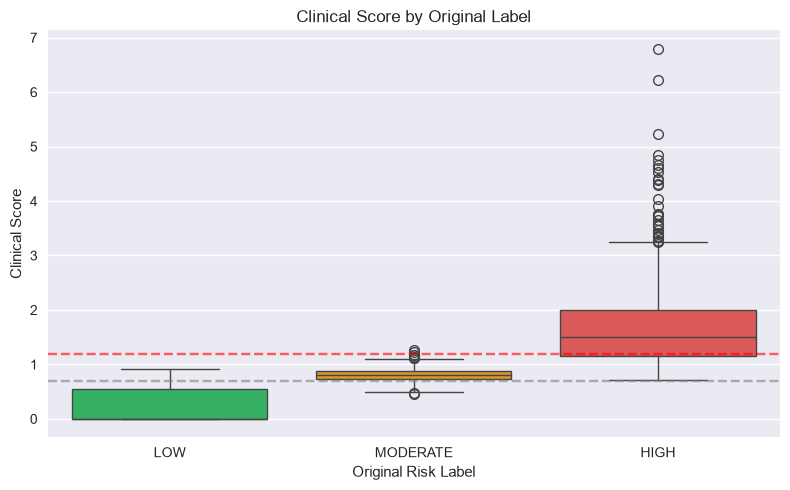

Saved: /Users/jade/GUIDAPLATE/outputs/figures/xgb_v3_04_score_by_original.png


In [8]:
# DIAGRAM 4 — Score box plot by original label
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='risk_label_original', y='clinical_score', order=RISK_CLASSES,
            palette={'LOW': '#22c55e', 'MODERATE': '#f59e0b', 'HIGH': '#ef4444'}, ax=ax)
ax.axhline(0.7, color='gray', linestyle='--', alpha=0.6)
ax.axhline(1.2, color='red', linestyle='--', alpha=0.6)
ax.set_title('Clinical Score by Original Label')
ax.set_xlabel('Original Risk Label')
ax.set_ylabel('Clinical Score')
plt.tight_layout()
plt.savefig(FIG_DIR / 'xgb_v3_04_score_by_original.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "xgb_v3_04_score_by_original.png"}')


## Section 4 — Save


In [9]:
if pct_changed > 30:
    print(f'⚠ WARNING: {pct_changed:.1f}% of labels changed (>30%). Continuing with v3 labels.')
    print('Most changes occur at MODERATE boundaries where the weighted clinical score')
    print('captures gradual nutrient burden rather than discrete exceedance counts.')

export = df[[
    'SEQN', 'ckd_stage', 'potassium', 'phosphorus', 'protein_per_kg', 'sodium',
]].copy()
export['risk_label'] = df['risk_label_v3']
export['clinical_score'] = df['clinical_score']
export['risk_label_original'] = df['risk_label_original']

out_path = STATS_DIR / '05_risk_labels_v3.csv'
export.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Rows: {len(export)}')
print('NOTEBOOK 03c COMPLETE')


Saved: /Users/jade/GUIDAPLATE/outputs/stats/05_risk_labels_v3.csv
Rows: 1862
NOTEBOOK 03c COMPLETE
